Generando el fractal de Julia
Entrenando ambas redes por 500 épocas...
Época 100 | Loss MLP: 0.01560 | Loss KAN: 0.01070
Época 200 | Loss MLP: 0.01187 | Loss KAN: 0.00780
Época 300 | Loss MLP: 0.01005 | Loss KAN: 0.00641
Época 400 | Loss MLP: 0.00900 | Loss KAN: 0.00558
Época 500 | Loss MLP: 0.00827 | Loss KAN: 0.00510


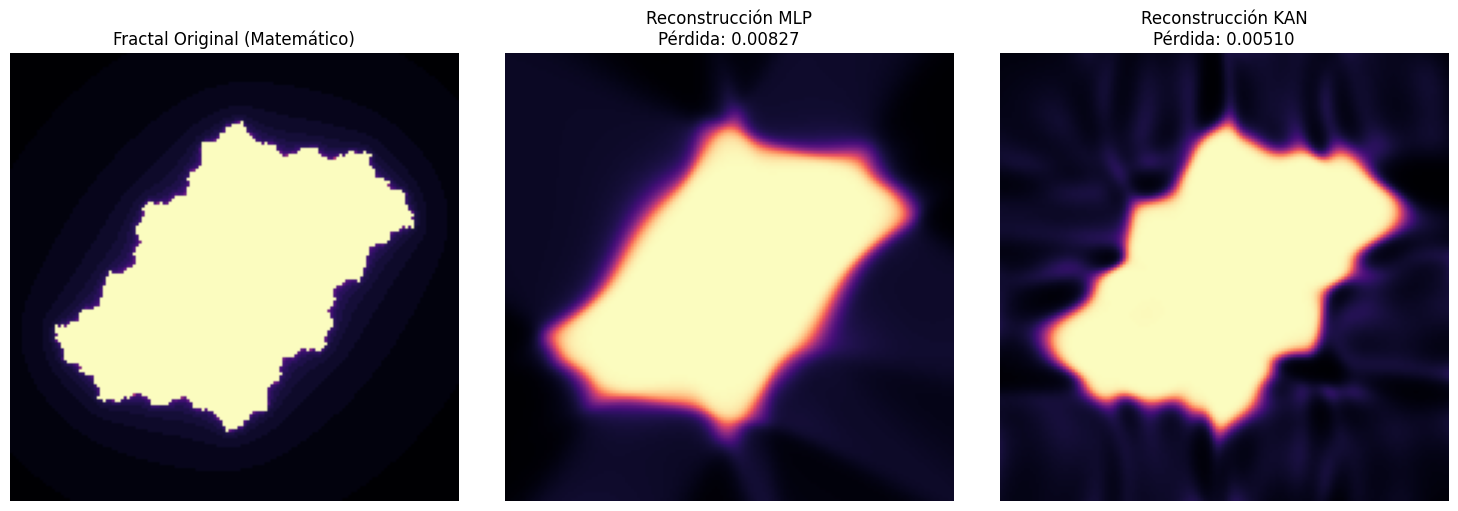

In [ ]:
import torch
import torch.nn as nn
import torch.optim as optim
import numpy as np
import matplotlib.pyplot as plt

# 1. GENERACIÓN DEL DATASET: FRACTAL (Conjunto de Julia)
def generate_julia_set(res=100):
    x=np.linspace(-1.5,1.5,res)
    y=np.linspace(-1.5,1.5,res)
    X,Y=np.meshgrid(x, y)

    c = -0.123 + 0.456j # Parámetro complejo del fractal
    Z=X+1j*Y
    img=np.zeros(Z.shape)

    for i in range(40): # Iteraciones del fractal
        mask=np.abs(Z)<10
        Z[mask]=Z[mask]**2+c
        img[mask]+=1
    img=img/40.0        # Normalizamos a [0, 1]

    # Preparamos los datos para la red: Entrada (x, y) -> Salida (intensidad)
    coords=np.stack([X.ravel(), Y.ravel()], axis=1)
    intensities=img.ravel()[:, None]
    return torch.tensor(coords, dtype=torch.float32), torch.tensor(intensities, dtype=torch.float32), img

print("Generando el fractal de Julia")
X_train, y_train, img_original=generate_julia_set(res=150) # Imagen alta definición
device=torch.device('cuda' if torch.cuda.is_available() else 'cpu')
X_train, y_train=X_train.to(device), y_train.to(device)


# 2. RED 1: MLP
class MLP_INR(nn.Module):
    def __init__(self):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(2, 64), nn.Tanh(),
            nn.Linear(64, 64), nn.Tanh(),
            nn.Linear(64, 1), nn.Sigmoid()
        )
    def forward(self, x):
        return self.net(x)


# 3. RED 2: KAN (Con Polinomios de Chebyshev)
class ChebyKANLayer(nn.Module):
    def __init__(self, in_features, out_features, degree=4):
        super().__init__()
        self.in_features=in_features
        self.out_features=out_features
        self.degree=degree
        # Los coeficientes polinómicos son los pesos que vamos a aprender
        self.coeffs=nn.Parameter(torch.randn(out_features, in_features, degree + 1) * 0.1)

    def forward(self, x):
        x=torch.tanh(x) # Normalizamos a [-1, 1] para Chebyshev

        # T_0(x) = 1, T_1(x) = x
        cheby_terms=[torch.ones_like(x), x]
        # Relación de recurrencia: T_{n}(x) = 2x T_{n-1}(x) - T_{n-2}(x)
        for i in range(2, self.degree + 1):
            cheby_terms.append(2*x*cheby_terms[-1]-cheby_terms[-2])

        T=torch.stack(cheby_terms, dim=-1) # (batch, in_features, degree+1)

        # Multiplicamos los polinomios por los coeficientes y sumamos (einsum es magia)
        y=torch.einsum('bid,oid->bo', T, self.coeffs)
        return y

class KAN_INR(nn.Module):
    def __init__(self):
        super().__init__()
        # Misma estructura aproximada de neuronas, pero con capas KAN
        self.kan1=ChebyKANLayer(2, 64, degree=5)
        self.kan2=ChebyKANLayer(64, 1, degree=5)

    def forward(self, x):
        x=self.kan1(x)
        x=self.kan2(x)
        return torch.sigmoid(x)


# 4. ENTRENAMIENTO COMPARATIVO
model_mlp=MLP_INR().to(device)
model_kan=KAN_INR().to(device)

opt_mlp=optim.Adam(model_mlp.parameters(), lr=0.01)
opt_kan=optim.Adam(model_kan.parameters(), lr=0.01)
criterion=nn.MSELoss()

epochs=500
print(f"Entrenando ambas redes por {epochs} épocas...")

for epoch in range(epochs):
    # Train MLP
    opt_mlp.zero_grad()
    pred_mlp=model_mlp(X_train)
    loss_mlp=criterion(pred_mlp, y_train)
    loss_mlp.backward()
    opt_mlp.step()

    # Train KAN
    opt_kan.zero_grad()
    pred_kan=model_kan(X_train)
    loss_kan=criterion(pred_kan, y_train)
    loss_kan.backward()
    opt_kan.step()

    if (epoch + 1) % 100 == 0:
        print(f"Época {epoch+1} | Loss MLP: {loss_mlp.item():.5f} | Loss KAN: {loss_kan.item():.5f}")


# 5. VISUALIZACIÓN DE RESULTADOS
res = int(np.sqrt(X_train.shape[0])) # Calcula automáticamente que es 256 (la raíz de 65536)

with torch.no_grad():
    img_mlp = model_mlp(X_train).view(res, res).cpu().numpy()
    img_kan = model_kan(X_train).view(res, res).cpu().numpy()

fig, axes = plt.subplots(1, 3, figsize=(15, 5))

axes[0].imshow(img_original, cmap='magma')
axes[0].set_title("Fractal Original (Matemático)")
axes[0].axis('off')

axes[1].imshow(img_mlp, cmap='magma')
axes[1].set_title(f"Reconstrucción MLP\nPérdida: {loss_mlp.item():.5f}")
axes[1].axis('off')

axes[2].imshow(img_kan, cmap='magma')
axes[2].set_title(f"Reconstrucción KAN\nPérdida: {loss_kan.item():.5f}")
axes[2].axis('off')

plt.tight_layout()
plt.show()

Iniciando evaluación de 3 fractales en cpu...

--- Entrenando Fractal 1/3 | c = (-0.123+0.745j) ---
Finalizado -> MSE MLP: 0.01548 | MSE KAN: 0.00967

--- Entrenando Fractal 2/3 | c = (-0.4+0.6j) ---
Finalizado -> MSE MLP: 0.01749 | MSE KAN: 0.01099

--- Entrenando Fractal 3/3 | c = (-0.8+0.156j) ---
Finalizado -> MSE MLP: 0.01423 | MSE KAN: 0.00963


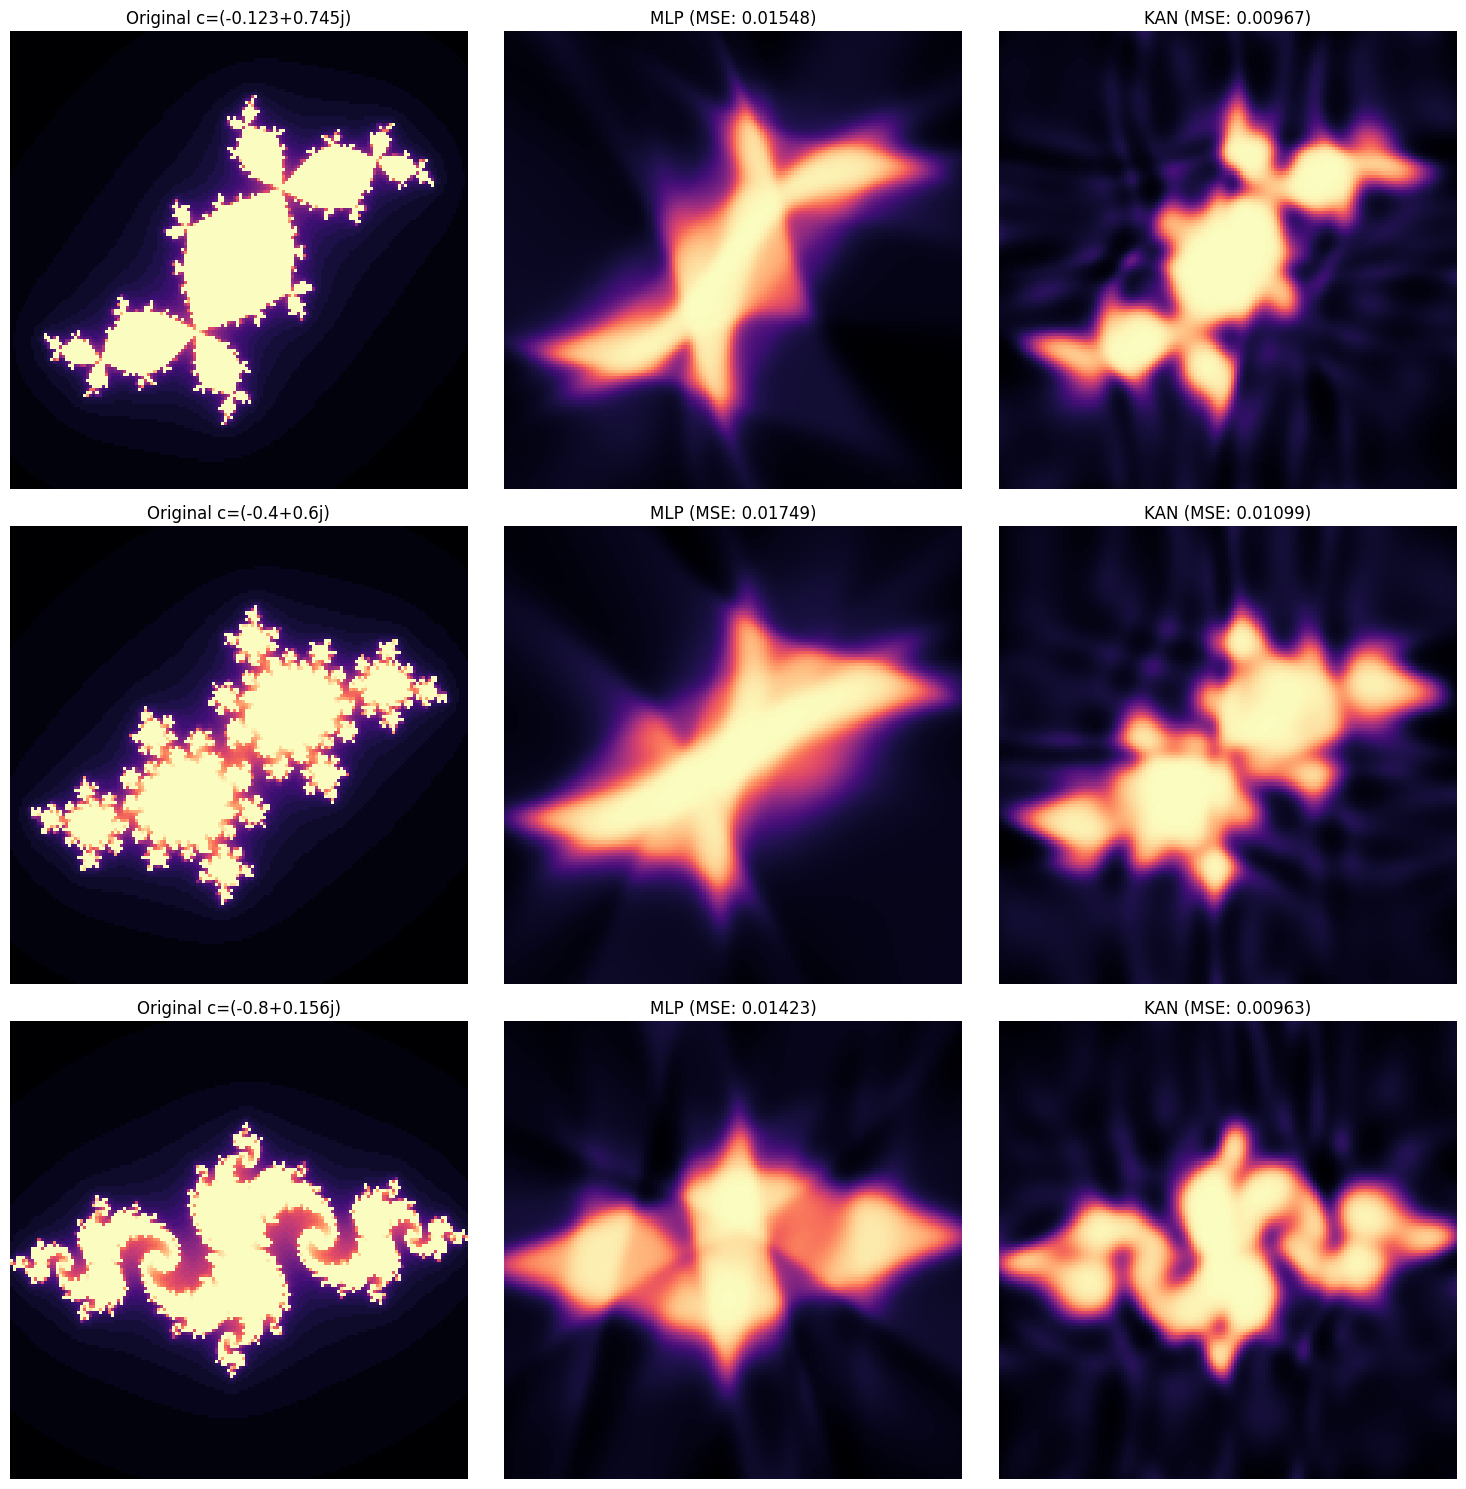

In [ ]:
import torch
import torch.nn as nn
import torch.optim as optim
import numpy as np
import matplotlib.pyplot as plt

# 1. GENERADOR DE FRACTALES PARAMETRIZADO
def generate_julia_set(c, res=150):
    x=np.linspace(-1.5, 1.5, res)
    y=np.linspace(-1.5, 1.5, res)
    X, Y=np.meshgrid(x, y)

    Z=X+1j*Y
    img=np.zeros(Z.shape)

    for i in range(40):
        mask=np.abs(Z) < 10
        Z[mask]=Z[mask]**2 + c
        img[mask]+=1

    img=img/40.0
    coords=np.stack([X.ravel(), Y.ravel()], axis=1)
    intensities=img.ravel()[:, None]

    return torch.tensor(coords, dtype=torch.float32), torch.tensor(intensities, dtype=torch.float32), img

# 2. ARQUITECTURAS
class MLP_INR(nn.Module):
    def __init__(self):
        super().__init__()
        self.net=nn.Sequential(
            nn.Linear(2, 64), nn.Tanh(),
            nn.Linear(64, 64), nn.Tanh(),
            nn.Linear(64, 1), nn.Sigmoid()
        )
    def forward(self, x):
        return self.net(x)

class ChebyKANLayer(nn.Module):
    def __init__(self, in_features, out_features, degree=4):
        super().__init__()
        self.in_features, self.out_features, self.degree=in_features, out_features, degree
        self.coeffs=nn.Parameter(torch.randn(out_features, in_features, degree + 1) * 0.1)

    def forward(self, x):
        x=torch.tanh(x)
        cheby_terms=[torch.ones_like(x), x]
        for i in range(2, self.degree + 1):
            cheby_terms.append(2*x*cheby_terms[-1]-cheby_terms[-2])
        T=torch.stack(cheby_terms, dim=-1)
        return torch.einsum('bid,oid->bo', T, self.coeffs)

class KAN_INR(nn.Module):
    def __init__(self):
        super().__init__()
        self.kan1=ChebyKANLayer(2, 64, degree=5)
        self.kan2=ChebyKANLayer(64, 1, degree=5)
    def forward(self, x):
        return torch.sigmoid(self.kan2(self.kan1(x)))

# 3. BUCLE
device=torch.device('cuda' if torch.cuda.is_available() else 'cpu')

# Lista de parámetros
lista_c = [
    -0.123 + 0.745j,
    -0.4 + 0.6j,
    -0.8 + 0.156j
]

epochs=500
resultados=[]


for idx, c_val in enumerate(lista_c):
    print(f"\n--- Entrenando Fractal {idx+1}/{len(lista_c)} | c = {c_val} ---")

    # 1. Generar datos
    X_train, y_train, img_orig=generate_julia_set(c=c_val, res=150)
    X_train, y_train=X_train.to(device), y_train.to(device)

    # 2. INSTANCIAR REDES NUEVAS
    model_mlp=MLP_INR().to(device)
    model_kan=KAN_INR().to(device)

    opt_mlp=optim.Adam(model_mlp.parameters(), lr=0.01)
    opt_kan=optim.Adam(model_kan.parameters(), lr=0.01)
    criterion=nn.MSELoss()

    # 3. Entrenar
    for epoch in range(epochs):
        # MLP
        opt_mlp.zero_grad()
        loss_mlp=criterion(model_mlp(X_train), y_train)
        loss_mlp.backward()
        opt_mlp.step()

        # KAN
        opt_kan.zero_grad()
        loss_kan=criterion(model_kan(X_train), y_train)
        loss_kan.backward()
        opt_kan.step()

    print(f"Finalizado -> MSE MLP: {loss_mlp.item():.5f} | MSE KAN: {loss_kan.item():.5f}")

    # 4. Guardar inferencia
    with torch.no_grad():
        res=int(np.sqrt(X_train.shape[0]))
        img_mlp=model_mlp(X_train).view(res, res).cpu().numpy()
        img_kan=model_kan(X_train).view(res, res).cpu().numpy()
    resultados.append((c_val, img_orig, img_mlp, img_kan, loss_mlp.item(), loss_kan.item()))

# 4. VISUALIZACIÓN GLOBAL (Matriz de imágenes)
fig, axes=plt.subplots(len(lista_c), 3, figsize=(15, 5 * len(lista_c)))

for i, (c_val, orig, mlp, kan, l_mlp, l_kan) in enumerate(resultados):
    # Original
    axes[i, 0].imshow(orig, cmap='magma')
    axes[i, 0].set_title(f"Original c={c_val}")
    axes[i, 0].axis('off')

    # MLP
    axes[i, 1].imshow(mlp, cmap='magma')
    axes[i, 1].set_title(f"MLP (Pérdida: {l_mlp:.5f})")
    axes[i, 1].axis('off')

    # KAN
    axes[i, 2].imshow(kan, cmap='magma')
    axes[i, 2].set_title(f"KAN (Pérdida: {l_kan:.5f})")
    axes[i, 2].axis('off')

plt.tight_layout()
plt.show()